<a href="https://colab.research.google.com/github/gilangf03/Tugas-Pertemuan4/blob/main/segmentasi_kendaraan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from google.colab import files
uploaded = files.upload()

Saving baru.jpg to baru.jpg


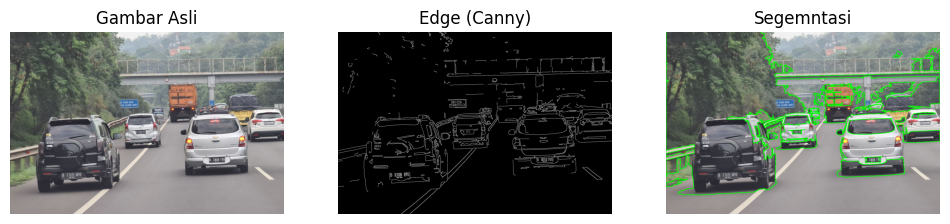

In [20]:
# Baca gambar
image = cv2.imread('baru.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Threshold
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Cari kontur
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy gambar untuk hasil akhir
outline = image_rgb.copy()

# Gambar garis tepi (bukan isi)
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 500:
        continue

    # Gambar garis kontur (warna hijau, tebal 2)
    cv2.drawContours(outline, [cnt], -1, (0,255,0), 2)

# Alternatif: pakai edge detection (lebih halus)
edges = cv2.Canny(blur, 100, 200)

# Tampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Gambar Asli")
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Edge (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Segmentasi")
plt.imshow(outline)
plt.axis('off')

plt.show()